# Clustering với k-Means

In [1]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt

np.set_printoptions(precision=3, suppress=True)

## 1. Dữ liệu giả định

**Giả sử có 3 tập**
1. Set 1: 50 điểm
1. Set 2: 75 điểm
1. Set 3: 100 điểm

In [2]:
np.random.seed(1)
x1,y1 = np.random.normal(loc=2,scale=1,size=50), np.random.normal(loc=5,scale=1,size=50)
x2,y2 = np.random.normal(loc=5,scale=1,size=75), np.random.normal(loc=1,scale=1,size=75)
x3,y3 = np.random.normal(loc=8,scale=1,size=100), np.random.normal(loc=7,scale=1,size=100)

**=== Hiển thị 3 tập để kiểm tra ===**

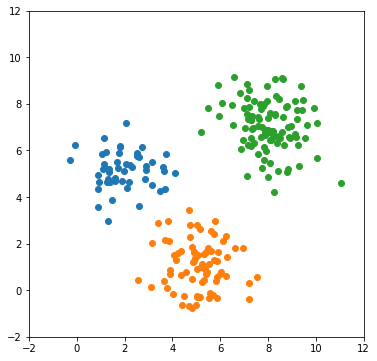

In [3]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(x1, y1)
plt.scatter(x2, y2)
plt.scatter(x3, y3)
plt.show()

### Ghép nối dữ liệu lại thành 1 tập chưa được clustered

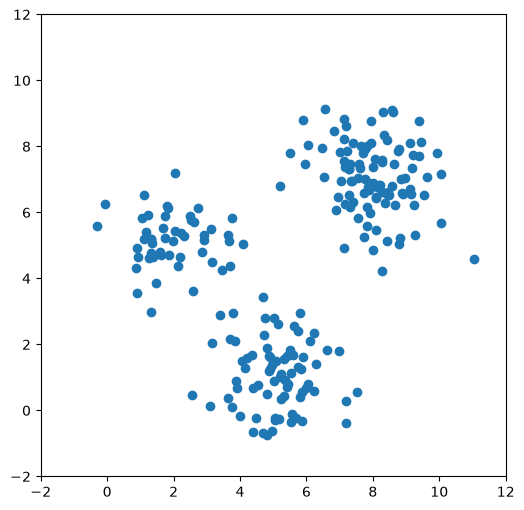

In [3]:
X = np.concatenate([x1, x2, x3])
Y = np.concatenate([y1, y2, y3])

fig = plt.figure(figsize=(6,6))

plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(X, Y)

plt.show()


In [4]:
dat2 = np.stack([x2,y2]).T
dat3 = np.stack([x3,y3]).T

**=== Tập dữ liệu giả định có 225 dòng, 2 cột (x,y) ===**

In [5]:
dat1 = np.stack([x1, y1]).T
dat2 = np.stack([x2, y2]).T
dat3 = np.stack([x3, y3]).T

data = np.vstack([dat1, dat2, dat3])


### Sắp ngẫu nhiên các dòng

In [6]:
np.random.seed(2)
np.random.shuffle(data)

### Kiểm tra lại với biểu đồ scatter

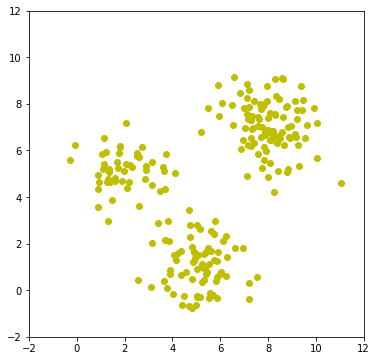

In [8]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(dat[:,0], dat[:,1], color='y')
plt.show()

## 2. Thực hiện phân cụm

### 2.1. Giả sử K=3 và tìm 3 điểm ban đầu ngẫu nhiên

In [9]:
K = 3

In [7]:
np.random.seed(30)
initial_centers = data[np.random.choice(len(data), 3, replace=False)]


**Gán các trung tâm cho 3 điểm này**

In [10]:
centers = initial_centers.copy()
print(centers)

[[5.338 0.438]
 [2.617 5.698]
 [4.9   1.243]]


**=== Vẽ K điểm centroids ban đầu lên biểu đồ ===**

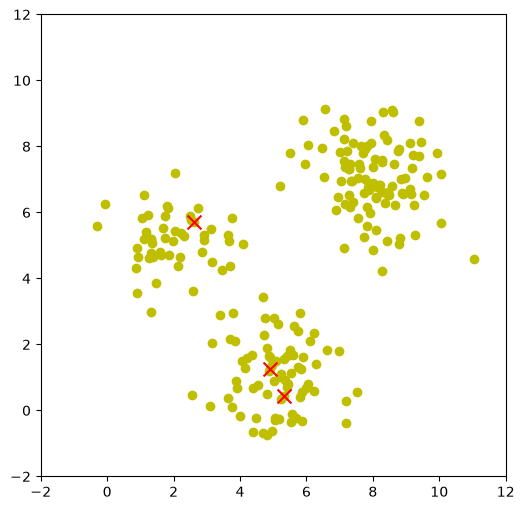

In [12]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(data[:,0], data[:,1], color='y')
plt.scatter(centers[:,0], centers[:,1], color='r', marker='x', s=100)
plt.show()

### 2.2. Tiến hành gom cụm lần 1

**=== Khởi tạo K danh sách rỗng (để chứa các điểm của mỗi cluster) ===**

In [13]:
cList = [[] for _ in range(3)]

print(cList)

[[], [], []]


**=== Với mỗi sample, tìm xem nó gần điểm centroid nào nhất ===**

In [15]:
for sample in data:
   distances = np.linalg.norm(centers - sample, axis=1)
   cluster = np.argmin(distances)
   cList[cluster].append(sample)
    

In [17]:
# Thử kiểm tra lại mỗi list
K = 3
for i in range(K): print(len(cList[i]))

29
138
58


**=== Thử lấy cluster đầu tiên ra và đánh giá ===**

In [18]:
np.stack(cList[0]).shape

(29, 2)

In [20]:
# Tọa độ của điểm centroid mới
new_centers = np.array([np.mean(cluster, axis=0) for cluster in cList])
print(new_centers)

[[5.584 0.19 ]
 [5.764 6.535]
 [5.594 2.377]]


**=== Tính lại các điểm centroids ===**

In [21]:
centroids = np.array([np.mean(cluster, axis=0) for cluster in cList])
print(centroids)

[[5.584 0.19 ]
 [5.764 6.535]
 [5.594 2.377]]


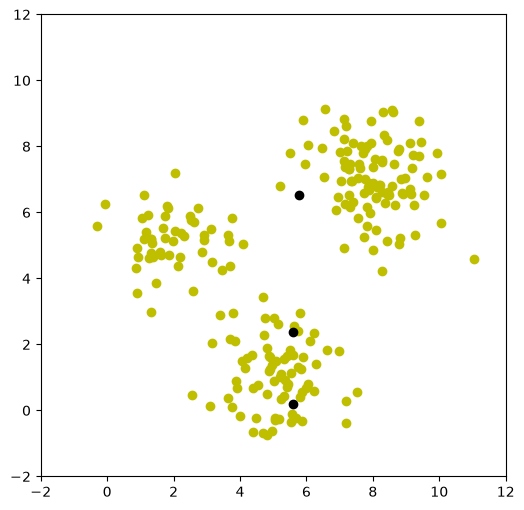

In [23]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(data[:,0], data[:,1], color='y')
plt.scatter(centroids[:,0], centroids[:,1], color='k')

plt.show()

### 2.3. Tiến hành gom cụm lần 2

**=== Tiếp tục khởi tạo K list rỗng để chứa các cluster mới ===**

In [25]:
cList = [[] for _ in range(K)]
for sample in data:
    kq = np.sum((sample - centroids)**2, axis=1)
    min_d_idx = np.argmin(kq)
    cList[min_d_idx].append(sample)

# Tính giá trị của các centroids mới
centroids = [np.stack(cList[i]).mean(axis=0) for i in range(K)]
centroids = np.stack(centroids)
print(centroids)

[[5.099 0.36 ]
 [6.268 6.612]
 [4.451 2.574]]


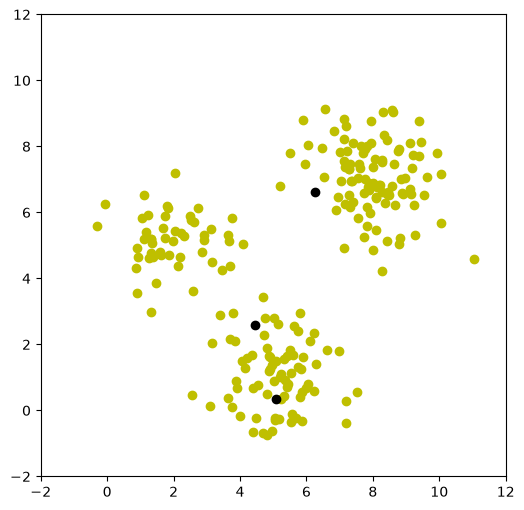

In [26]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(data[:,0], data[:,1], color='y')
plt.scatter(centroids[:,0], centroids[:,1], color='k')

plt.show()

### 2.4. Tiến hành gom cụm lần 3

**=== Tiếp tục khởi tạo K list rỗng để chứa các cluster mới ===**

In [27]:
cList = [[] for _ in range(K)]
for sample in data:
    kq = np.sum((sample - centroids)**2, axis=1)
    min_d_idx = np.argmin(kq)
    cList[min_d_idx].append(sample)

centroids = [np.stack(cList[i]).mean(axis=0) for i in range(K)]
centroids = np.stack(centroids)
print(centroids)

[[5.225 0.569]
 [7.744 7.031]
 [2.898 4.079]]


**==> Nhận xét: các giá trị trung tâm gần như ít thay đổi**

In [ ]:
# Lấy ra các clusterprint("Centroid ban đầu:")
# Sau lần gán cụm đầu tiên, các centroid có sự thay đổi đáng kể. Đặc biệt centroid 2 và 3 thay đổi nhiều, cho thấy các điểm dữ liệu chưa được phân cụm ổn định và cần tiếp tục lặp lại quá trình gán cụm và cập nhật centroid.




[[5.338 0.438]
 [2.617 5.698]
 [4.9   1.243]]
Centroid sau khi tính lại:
[[5.225 0.569]
 [7.744 7.031]
 [2.898 4.079]]
Độ thay đổi:
[0.173 5.297 3.472]


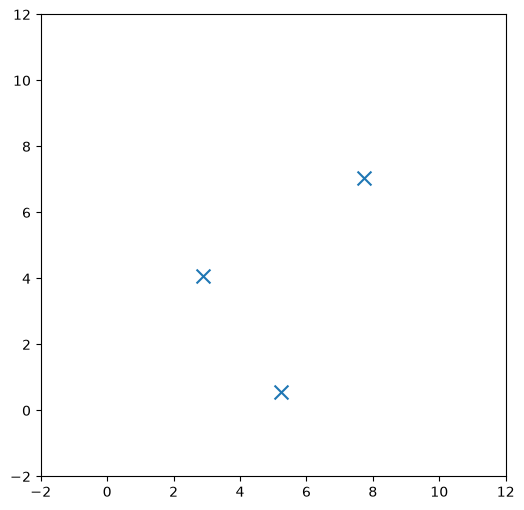

In [30]:
# Hiển thị 3 cluster lên biểu đồ
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(centroids[:, 0], centroids[:, 1], marker='x', s=100)

plt.show()